In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten
# from keras import optimizers
from tensorflow.keras import optimizers 

from sklearn.model_selection import train_test_split

In [2]:
cols_to_drop = ['latitude', 'longitude', 'city']
cols = ['aqi', 'temperature_2m', 'relative_humidity_2m', 
       'wind_speed_10m', 'pressure_msl', 'precipitation', 'cloud_cover', 'pm2.5','ozone']

In [3]:
df = pd.read_csv('Data/Final/San_Jose___Jackson.csv')
df.drop(cols_to_drop, axis=1, inplace=True)
df.set_index(['date'], inplace=True)
df = df[cols]
df.head()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone
date,,,,,,,,,
2014-01-01,154.0,10.993118,42.393568,8.427079,1021.341176,0.0,31.823529,60.4,0.015
2014-01-02,96.0,12.511500,41.723330,8.878908,1019.933333,0.0,44.041667,33.0,0.010
2014-01-03,95.0,14.938583,37.342059,7.806972,1017.075000,0.0,92.541667,32.6,0.010
2014-01-04,83.0,14.390667,40.825293,6.490594,1015.345833,0.0,55.375000,26.4,0.015
2014-01-05,70.0,11.257333,47.339449,7.805876,1018.612500,0.0,0.000000,19.5,0.018


### Normalize the dataset

In [4]:
minimum = []
maximum = []
minimum.append(df['aqi'].min())
maximum.append(df['aqi'].max())

cols = df.columns.values.tolist()

scaler = MinMaxScaler(feature_range=(0, 1))
df[cols] = scaler.fit_transform(df[cols])

df.head()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone
date,,,,,,,,,
2014-01-01,0.736842,0.223888,0.299862,0.226908,0.658160,0.0,0.318235,0.452718,0.135417
2014-01-02,0.459330,0.277988,0.291430,0.242174,0.622135,0.0,0.440417,0.248697,0.083333
2014-01-03,0.454545,0.364465,0.236308,0.205957,0.548992,0.0,0.925417,0.245719,0.083333
2014-01-04,0.397129,0.344943,0.280131,0.161481,0.504745,0.0,0.553750,0.199553,0.135417
2014-01-05,0.334928,0.233302,0.362088,0.205920,0.588336,0.0,0.000000,0.148176,0.166667


In [5]:
def create_lagged_features(df, lag_steps, target_col='pm2.5'):
    for lag in range(1, lag_steps + 1):
        df[f'{target_col}_(t-{lag})'] = df[target_col].shift(lag)
    return df


lag_steps = 2

df = create_lagged_features(df, lag_steps, target_col='aqi')

df = df.dropna()
df.head()

,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover,pm2.5,ozone,aqi_(t-1),aqi_(t-2)
date,,,,,,,,,,,
2014-01-03,0.454545,0.364465,0.236308,0.205957,0.548992,0.0,0.925417,0.245719,0.083333,0.459330,0.736842
2014-01-04,0.397129,0.344943,0.280131,0.161481,0.504745,0.0,0.553750,0.199553,0.135417,0.454545,0.459330
2014-01-05,0.334928,0.233302,0.362088,0.205920,0.588336,0.0,0.000000,0.148176,0.166667,0.397129,0.454545
2014-01-06,0.416268,0.276355,0.388041,0.146433,0.684721,0.0,0.484167,0.212956,0.010417,0.334928,0.397129
2014-01-07,0.416268,0.332027,0.384985,0.142131,0.666276,0.0,0.914167,0.213701,0.093750,0.416268,0.334928


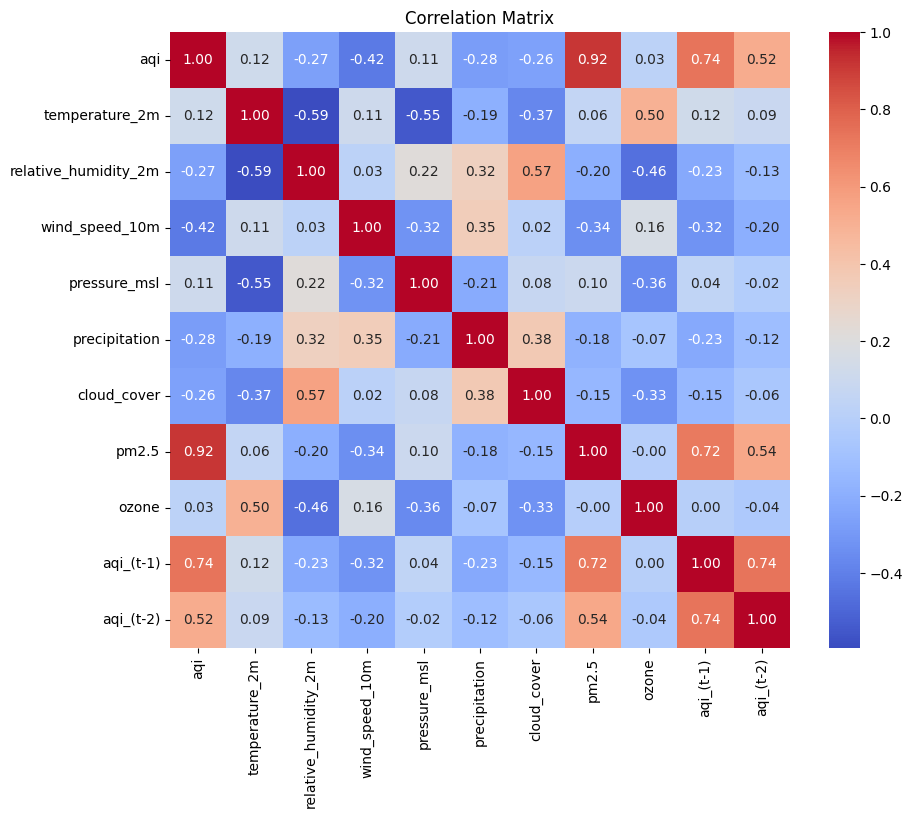

In [6]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
X = df.drop(columns=['aqi']).values
y = df['aqi'].values

temp1 = int(0.8*len(X))
temp2 = int(0.1*len(X))
X_train = X[:temp1]
X_val = X[temp1:temp1+temp2]
X_test = X[temp1+temp2:]

y_train = y[:temp1]
y_val = y[temp1:temp1+temp2]
y_test = y[temp1+temp2:]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(3287, 10) (410, 10) (412, 10)
(3287,) (410,) (412,)


In [8]:
look_back = 1
length_of_col = X_train.shape[1]

X_train = X_train.reshape((X_train.shape[0], look_back, length_of_col))
X_test = X_test.reshape((X_test.shape[0], look_back, length_of_col))
X_val = X_val.reshape((X_val.shape[0], look_back, length_of_col))

print(X_train.shape, X_val.shape, X_test.shape)

(3287, 1, 10) (410, 1, 10) (412, 1, 10)


In [9]:
epoch = 100
model = Sequential()


model.add((LSTM(units=64, return_sequences=True, input_shape=(look_back, X_train.shape[2]), activation='relu')))
model.add(Dropout(0.2))
model.add((LSTM(units=32, return_sequences=True, activation='relu')))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(units = 1, activation='sigmoid'))

# learning rate with decay
adam = optimizers.Adam(learning_rate=0.001)

model.compile(loss = 'mean_squared_error', optimizer = adam)

history = model.fit(X_train[:-1], y_train[1:], validation_data=(X_val[:-1], y_val[1:]), epochs=epoch, batch_size=50,verbose=1, shuffle = False)
model.summary()

Epoch 1/100


/Users/vgurumurthy/Downloads/aqiprediction-main/aqipred/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0828 - val_loss: 0.0330
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0162 - val_loss: 0.0079
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0101 - val_loss: 0.0073
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0095 - val_loss: 0.0069
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0090 - val_loss: 0.0064
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0086 - val_loss: 0.0061
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0079 - val_loss: 0.0059
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0076 - val_loss: 0.0055
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0072 - val_loss: 0.0054
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0068 - val_loss: 0.0052
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0066 - val_loss: 0.0052
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0066 - val_lo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,949 (370.90 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,300 (247.27 KB)

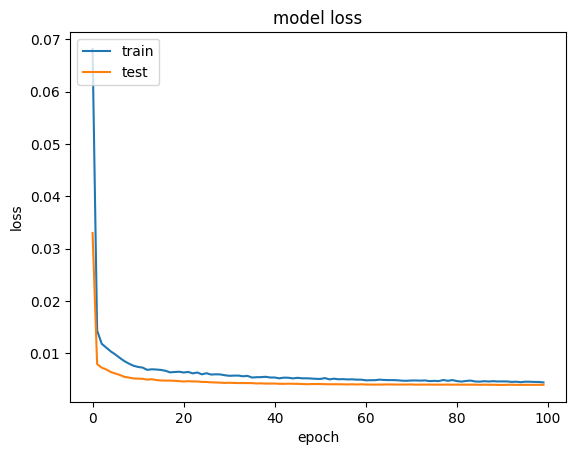

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

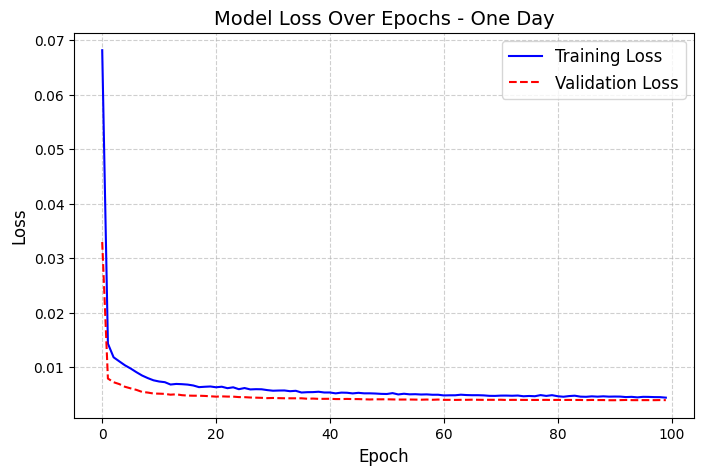

In [11]:
plt.figure(figsize=(8, 5))  # Set figure size for better readability

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss', color='blue', linestyle='solid')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='dashed')

# Titles and labels
plt.title('Model Loss Over Epochs - One Day', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Add a legend and grid for clarity
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

In [12]:
# Get the final loss values from history
final_train_loss_1day = history.history['loss'][-1]
final_val_loss_1day = history.history['val_loss'][-1]

print("1-Day Prediction Model:")
print(f"Final Training Loss: {final_train_loss_1day:.4f}")
print(f"Final Validation Loss: {final_val_loss_1day:.4f}")

1-Day Prediction Model:
Final Training Loss: 0.0044
Final Validation Loss: 0.0040


In [13]:
#attempted 7 day forecast with recursive apporach, ran in to errors and hence moved to different model for 7 day prediction
# def recursive_forecast_for_all(model, X_data, steps=7):
#     """
#     Perform 7-step ahead forecast for each row in X_test or X_train with updates to future rows.
    
#     Parameters:
#         model: Trained LSTM model.
#         X_data: Input dataset (X_test or X_train) as a 3D NumPy array (samples, timesteps, features).
#         steps: Number of steps (days) to forecast.
    
#     Returns:
#         List of predictions for each row in X_data.
#     """
#     all_predictions = []  # Store predictions for all rows

#     for row in range(len(X_data)-steps+1):
#         predictions = []  # Store predictions for the current row
#         X_data_copy = X_data.copy()  # Copy the original dataset to preserve it

#         for i in range(steps):
#             # Ensure we do not exceed dataset bounds
#             if row + i >= len(X_data):
#                 break

#             # Extract current row input
#             temp_input = X_data_copy[row + i].copy()  # Shape (1, 9)

#             # Reshape for LSTM input: (samples=1, timesteps=1, features=9)
#             temp_input_reshaped = temp_input.reshape(1, 1, -1)

#             # Predict the next AQI value
#             pred = model.predict(temp_input_reshaped, verbose=0)
#             predictions.append(pred[0][0])  # Store the prediction

#             # Update lagged AQI values in the next row (if within bounds)
#             if row + i + 1 < len(X_data_copy):
#                 X_data_copy[row + i + 1][0][-2:] = [pred[0][0], temp_input[0][-2]]  # Update aqi_t-1 and aqi_t-2

#         all_predictions.append(predictions)  # Store the 7-step forecast for this row

#     return all_predictions



# seven_day_forecast = recursive_forecast_for_all(model, X_test, steps=7)
# # print("7-Day Forecasted AQI:", seven_day_forecast)

In [14]:
def recursive_forecast_for_all(model, X_data, steps=2):
    all_predictions = []  # Store predictions for all rows

    for row in range(len(X_data)):
        predictions = [np.nan] * steps
        X_data_copy = X_data.copy()  

        for i in range(steps):
            if row + i >= len(X_data):
                break

            temp_input = X_data_copy[row + i].copy()
            temp_input_reshaped = temp_input.reshape(1, 1, -1)
            pred = model.predict(temp_input_reshaped, verbose=0)
            predictions[i] = pred[0][0] 
            if row + i + 1 < len(X_data_copy):
                X_data_copy[row + i + 1][0][-2:] = [pred[0][0], temp_input[0][-2]]  

        all_predictions.append(predictions)

    return all_predictions

one_day_forecast = recursive_forecast_for_all(model, X_test, steps=7)

In [15]:
forecast_length = len(one_day_forecast)
test_df = df[-forecast_length:].copy()

columns = [f"pred_aqi_(t+{i})" if i > 0 else "pred_aqi" for i in range(1,len(one_day_forecast[0])+1)]


forecast_df = pd.DataFrame(one_day_forecast, columns=columns)
forecast_df.index = test_df.index
forecast_df['aqi_(t+1)'] = test_df['aqi'].shift(-1)

forecast_df = forecast_df * (maximum[0] - minimum[0]) + minimum[0]
forecast_df.tail(10)

,pred_aqi_(t+1),pred_aqi_(t+2),pred_aqi_(t+3),pred_aqi_(t+4),pred_aqi_(t+5),pred_aqi_(t+6),pred_aqi_(t+7),aqi_(t+1)
date,,,,,,,,
2025-03-25,54.105904,38.541975,38.607703,32.502928,34.332330,24.902082,31.655238,43.0
2025-03-26,38.496658,38.652428,32.501841,34.335127,24.902113,31.655254,30.656621,48.0
2025-03-27,38.271294,32.572247,34.308309,24.902856,31.655026,30.656624,36.321003,35.0
2025-03-28,32.479759,34.913423,24.912462,31.658312,30.656730,36.321128,35.954501,33.0
2025-03-29,34.805374,24.954917,31.654656,30.657178,36.320956,35.954532,NaN,17.0
2025-03-30,24.921400,31.645160,30.656814,36.320595,35.954535,NaN,NaN,29.0
2025-03-31,32.038048,30.572341,36.341442,35.949917,NaN,NaN,NaN,25.0
2025-04-01,30.568674,36.218015,35.956893,NaN,NaN,NaN,NaN,43.0
2025-04-02,36.536022,35.713849,NaN,NaN,NaN,NaN,NaN,43.0


In [16]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

# Assuming 'aqi_(t+1)' is the observed AQI column
for col in forecast_df.columns:
    if col.startswith("pred_aqi_"):
        # Extract lag from the column name, for example 'pred_aqi_(t+1)', 'pred_aqi_(t+2)'
        lag = int(col.split("_(t+")[1].strip(")")) if "(t+" in col else 0

        # Adjust 'aqi_(t+1)' based on its lag relationship with predictions
        actual_column = 'aqi_(t+1)'  # Adjust this if the observed AQI column has a different name
        actual = forecast_df[actual_column][lag:].reset_index(drop=True)
        predicted = forecast_df[col][:-lag].reset_index(drop=True)

        # Ensure lengths match
        min_len = min(len(actual), len(predicted))
        actual = actual[:min_len]
        predicted = predicted[:min_len]

        # Drop NaN values
        mask = ~np.isnan(actual) & ~np.isnan(predicted)
        actual = actual[mask]
        predicted = predicted[mask]

        # Check if non-empty after removing NaNs
        if len(actual) == 0 or len(predicted) == 0:
            print(f"Skipping column {col} due to insufficient data.")
            continue

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mape = np.mean(np.abs((actual - predicted) / actual)) * 100
        r2 = r2_score(actual, predicted)

        results.append({
            "Prediction Horizon": col,
            "RMSE": rmse,
            "R²": r2
        })

# Convert results to DataFrame
metrics_df = pd.DataFrame(results)
print(metrics_df)



  Prediction Horizon       RMSE        R²
0     pred_aqi_(t+1)  13.165967  0.298616
1     pred_aqi_(t+2)  13.185932  0.294553
2     pred_aqi_(t+3)  13.243838  0.285671
3     pred_aqi_(t+4)  13.258216  0.283554
4     pred_aqi_(t+5)  13.226250  0.288644
5     pred_aqi_(t+6)  13.209350  0.291954
6     pred_aqi_(t+7)  13.217454  0.292260


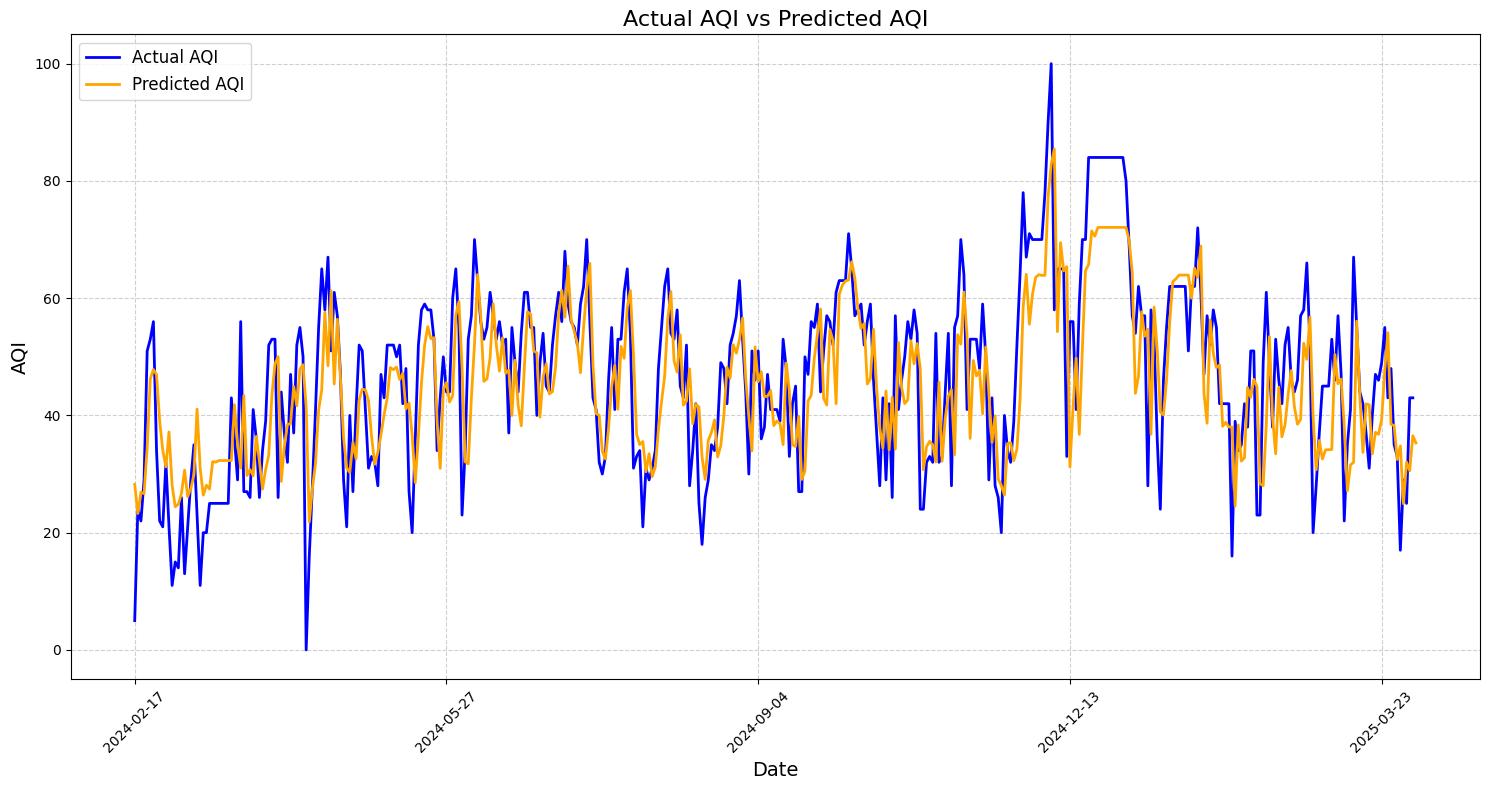

In [17]:


import matplotlib.pyplot as plt

# plt.figure(figsize=(15, 8))  # Set figure size
# ax = plt.gca()  # Get the current axis

# # Replace 'aqi' with the actual column name for the observed AQI
# forecast_df['aqi_(t+1)'].plot(ax=ax, label="Actual AQI", linestyle='-', linewidth=2, color='blue')

# # Replace 'pred_aqi' with the actual column name for the predicted AQI
# forecast_df['pred_aqi_(t+1)'].plot(ax=ax, label="Predicted AQI", linestyle='-', linewidth=2, color='orange')

# ax.set_title("Actual AQI vs Predicted AQI", fontsize=16)
# ax.set_xlabel("Date", fontsize=14)
# ax.set_ylabel("AQI", fontsize=14)

# ax.legend(loc="upper left", fontsize=12)

# # Rotate x-axis ticks for better visibility
# plt.xticks(rotation=45)

# # Add grid
# ax.grid(True, linestyle='--', alpha=0.6)

# # Show the plot
# plt.tight_layout()
# plt.show()
#Fixed plot code 
plt.figure(figsize=(15, 8))
ax = plt.gca()

if "aqi_(t+1)" in forecast_df and "pred_aqi_(t+1)" in forecast_df:
    forecast_df["aqi_(t+1)"].plot(ax=ax, label="Actual AQI", linestyle='-', linewidth=2, color='blue')
    forecast_df["pred_aqi_(t+1)"].plot(ax=ax, label="Predicted AQI", linestyle='-', linewidth=2, color='orange')

    ax.set_title("Actual AQI vs Predicted AQI", fontsize=16)
    ax.set_xlabel("Date", fontsize=14)
    ax.set_ylabel("AQI", fontsize=14)
    ax.legend(loc="upper left", fontsize=12)

    plt.xticks(rotation=45)
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Column names do not match! Check `forecast_df.columns` output.")


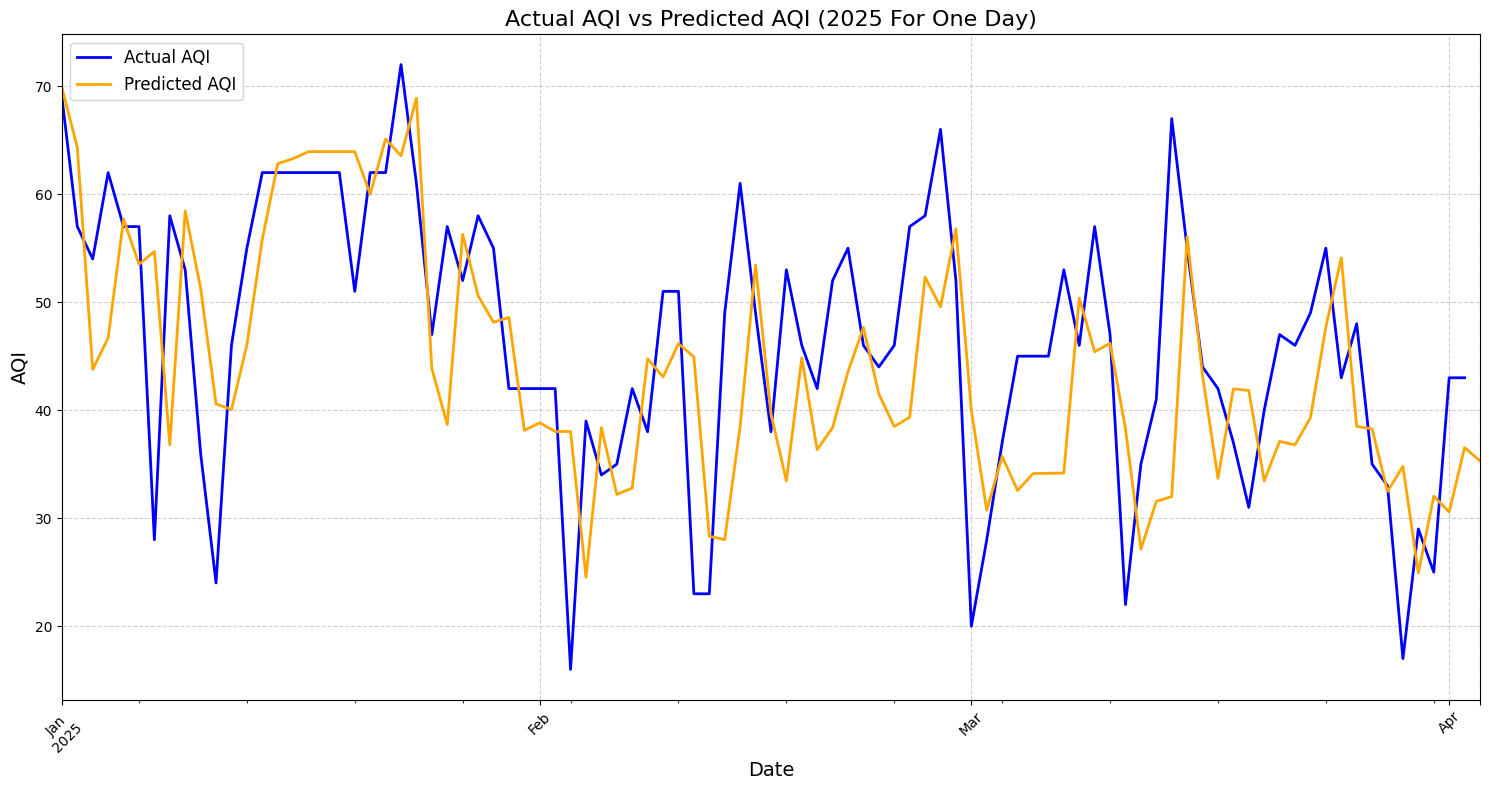

In [18]:
# Ensure the index is a DatetimeIndex
forecast_df.index = pd.to_datetime(forecast_df.index)

# Filter the data from 2024 onwards
forecast_df_2025 = forecast_df[forecast_df.index.year >= 2025]

# Plot the data
plt.figure(figsize=(15, 8))  # Set figure size
ax = plt.gca()  # Get the current axis

# Plot Actual AQI and Predicted AQI from 2024 onward
forecast_df_2025['aqi_(t+1)'].plot(ax=ax, label="Actual AQI", linestyle='-', linewidth=2, color='blue')
forecast_df_2025['pred_aqi_(t+1)'].plot(ax=ax, label="Predicted AQI", linestyle='-', linewidth=2, color='orange')

# Titles and labels
ax.set_title("Actual AQI vs Predicted AQI (2025 For One Day)", fontsize=16)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("AQI", fontsize=14)

ax.legend(loc="upper left", fontsize=12)

# Rotate x-axis ticks for better visibility
plt.xticks(rotation=45)

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()



